<a href="https://colab.research.google.com/github/rishike/llm_from_scratch/blob/main/SimplifiedAttentionMechanism.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implementing a simplified attention mechanism

In [1]:
import torch

In [2]:
inputs = torch.tensor(
    [[0.43, 0.15, 0.89],
     [0.55, 0.87, 0.66],
     [0.57, 0.85, 0.64],
     [0.22, 0.58, 0.33],
     [0.77, 0.25, 0.10],
     [0.05, 0.80, 0.55]
     ]
)

In [3]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [4]:
words = ['Your', 'journey', 'starts', 'with', 'one', 'step']

In [5]:
# extract x,y,z coordinates
x_coords = inputs[:, 0].numpy()
y_coords = inputs[:, 1].numpy()
z_coords = inputs[:, 2].numpy()

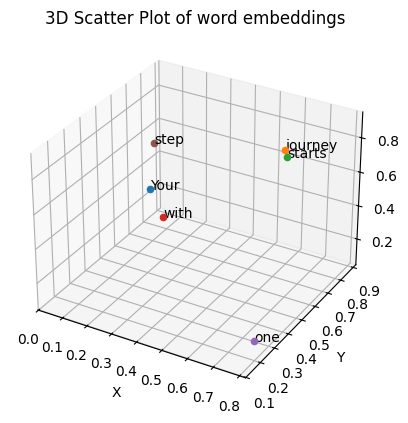

In [6]:
# create 3d plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for x,y,z, word in zip(x_coords, y_coords, z_coords, words):
    ax.scatter(x, y, z)
    ax.text(x, y, z, s=word, fontsize=10)


ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.title('3D Scatter Plot of word embeddings')
plt.show()


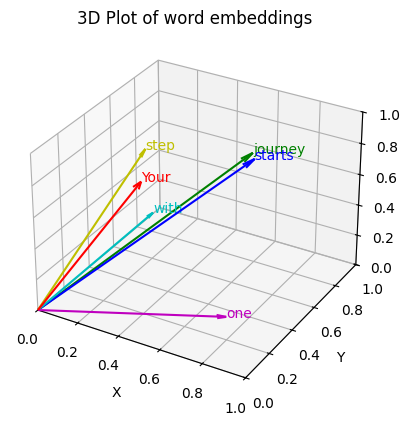

In [7]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

colors = ['r', 'g', 'b', 'c', 'm', 'y']

for (x,y,z, word, color) in zip(x_coords, y_coords, z_coords, words, colors):
  ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
  ax.text(x,y,z, word, fontsize=10, color=color)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])

plt.title('3D Plot of word embeddings')
plt.show()

In [8]:
query = inputs[1]

attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
  attn_scores_2[i] = torch.dot(query, x_i)

attn_scores_2

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])

In [9]:
query = inputs[0]

attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
  attn_scores_2[i] = torch.dot(query, x_i)

attn_scores_2

tensor([0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310])

In [10]:
query = inputs[2]

attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
  attn_scores_2[i] = torch.dot(query, x_i)

attn_scores_2

tensor([0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605])

In [11]:
query = inputs[3]

attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
  attn_scores_2[i] = torch.dot(query, x_i)

attn_scores_2

tensor([0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565])

In [12]:
query = inputs[4]

attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
  attn_scores_2[i] = torch.dot(query, x_i)

attn_scores_2

tensor([0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935])

Normalisation is a convention that is useful for interpretation and maintaing traning stablity in llm

Normalisation is to obtain attention weights that sum up to 1

In [13]:
attn_weights_2_tmp = attn_scores_2 / attn_scores_2.sum()

print("Attention weights:", attn_weights_2_tmp)
print("sum:" , attn_weights_2_tmp.sum())



Attention weights: tensor([0.1436, 0.2219, 0.2245, 0.1090, 0.2088, 0.0921])
sum: tensor(1.0000)


In practie, its more common and advisable to use the softmax function for normalization. This approach is better at managing extreme values and offers more favorable gradient properties

In [14]:
def softmax_naive(x):
  return torch.exp(x) / torch.exp(x).sum(dim=0)

In [15]:
attn_weights_2_naive = softmax_naive(attn_scores_2)

print("attention weights:", attn_weights_2_naive)
print("sum", attn_weights_2_naive.sum())

attention weights: tensor([0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295])
sum tensor(1.)


In [16]:
attn_weights_2 = torch.softmax(attn_scores_2, dim=0)

print("attention weights:", attn_weights_2)
print("sum", attn_weights_2.sum())

attention weights: tensor([0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295])
sum tensor(1.)


context vector

In [17]:
query = inputs[4]
context_vec_2 = torch.zeros(query.shape)
for i,x_i in enumerate(inputs):
  context_vec_2 += attn_weights_2[i]*x_i

print(context_vec_2)

tensor([0.4671, 0.5910, 0.5266])


Attention Score

In [18]:
attn_scores = torch.empty(6,6)
for i, x_i in enumerate(inputs):
  for j, x_j in enumerate(inputs):
    attn_scores[i, j] = torch.dot(x_i, x_j)

print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [19]:
attn_scors = inputs @ inputs.T
print(attn_scors)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [20]:
attn_weights = torch.softmax(attn_scores, dim=-1)
print(attn_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


Context Vector

In [21]:
all_context_vecs = attn_weights @ inputs
print(all_context_vecs)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])
